In [671]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder ,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns


In [623]:
df = pd.read_csv('loan.csv')

In [624]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [625]:
print(f"The No of rows {df.shape[0]} and No of columns {df.shape[1]}")

The No of rows 20000 and No of columns 36


In [626]:
df["LoanApproved"].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [627]:
df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

In [628]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [629]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='bar', color='steelblue')
    plt.title('Missing Values per Column', fontsize=14)
    plt.ylabel('Number of Missing Entries')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values in the dataset.")

✅ No missing values in the dataset.


In [630]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


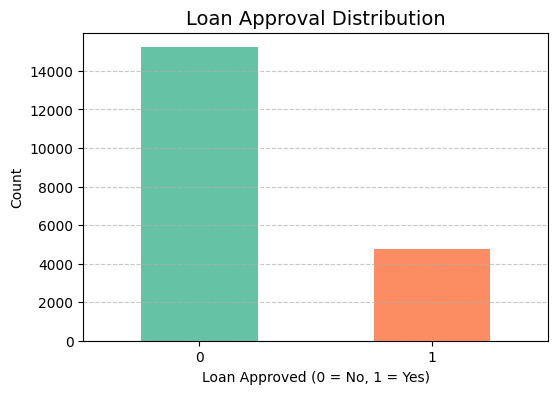

In [631]:
plt.figure(figsize=(6, 4))
df['LoanApproved'].value_counts().plot(kind='bar', color=['#66c2a5', '#fc8d62'])
plt.title('Loan Approval Distribution', fontsize=14)
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

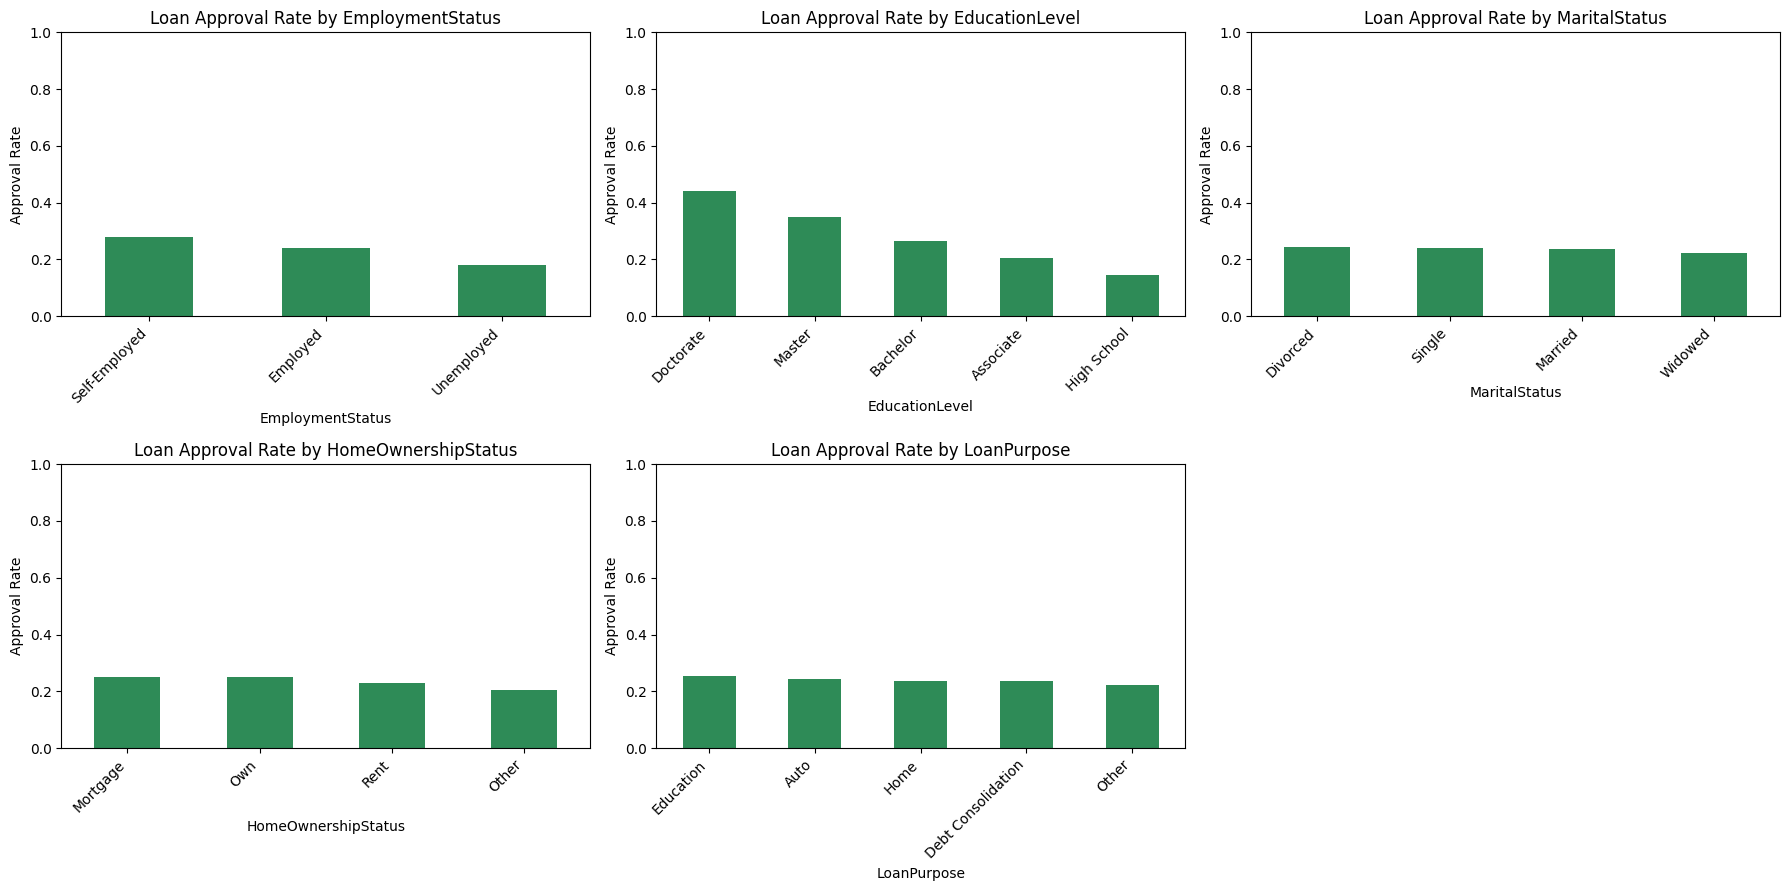

In [632]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    approval_rate = df.groupby(col)['LoanApproved'].mean().sort_values(ascending=False)
    approval_rate.plot(kind='bar', color='seagreen')
    plt.title(f'Loan Approval Rate by {col}')
    plt.ylabel('Approval Rate')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
plt.tight_layout()
plt.show()

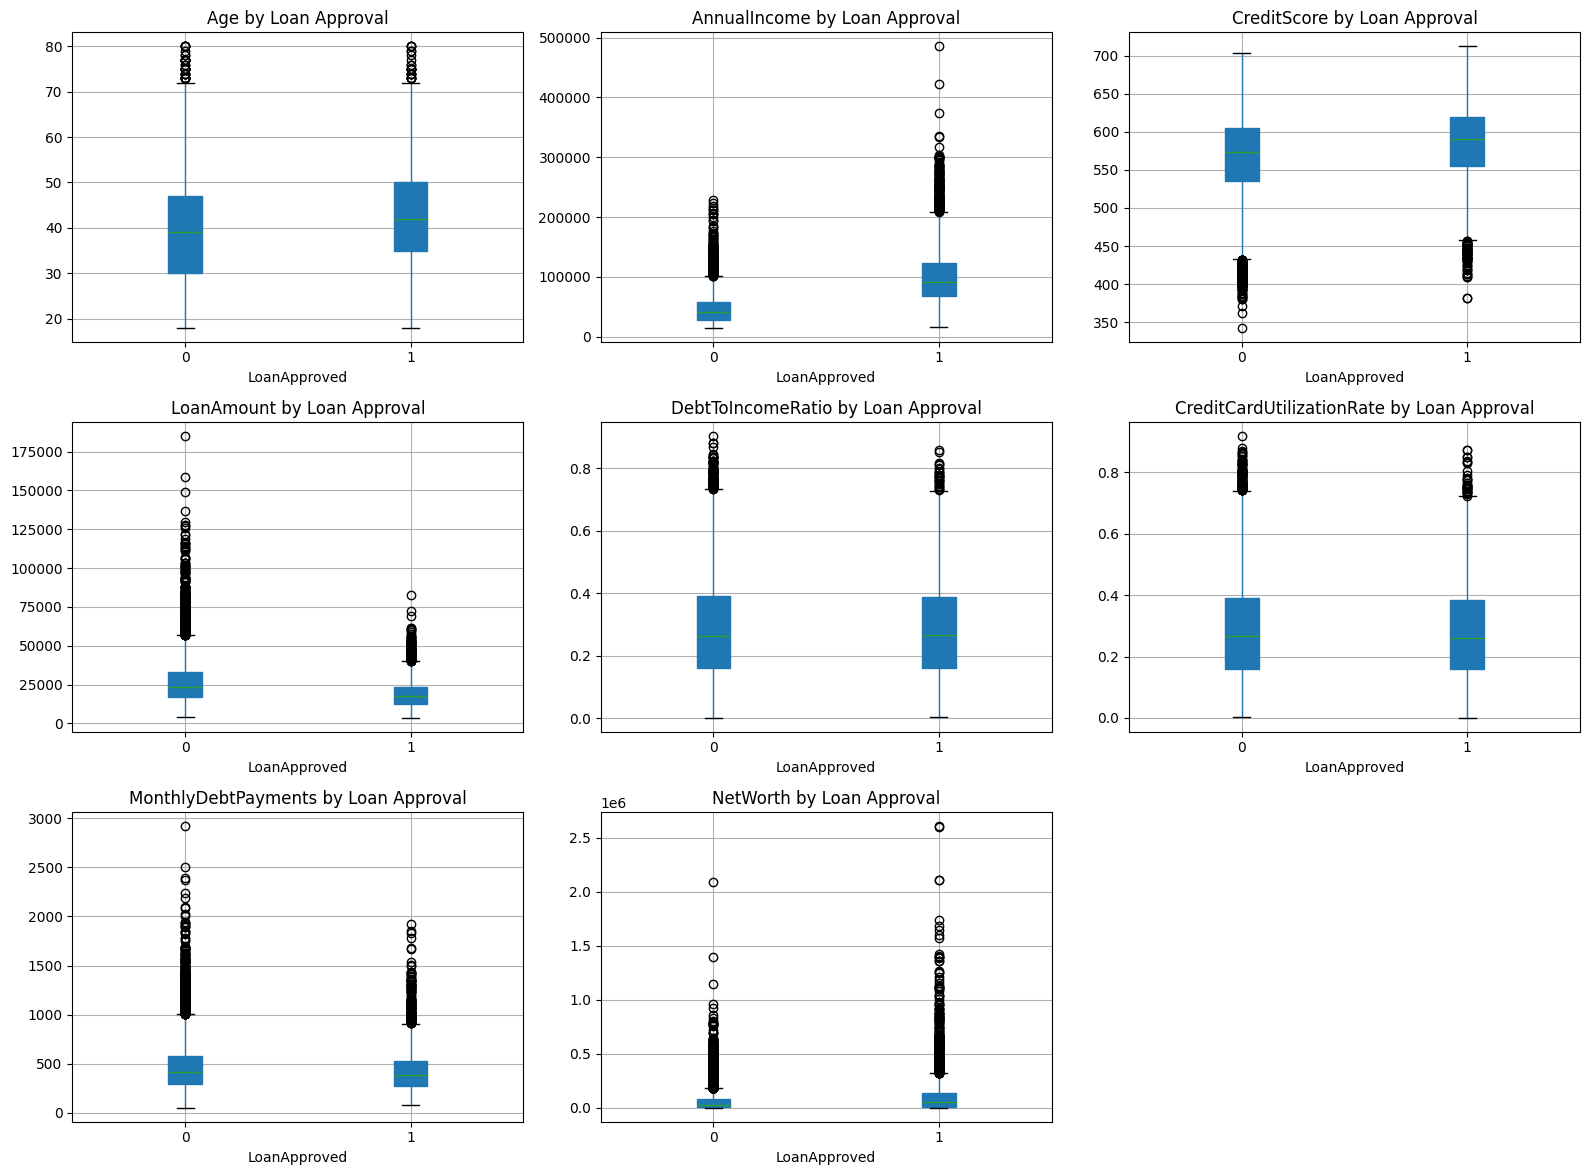

In [633]:
# Pick top 8 most relevant numeric features (avoid too many plots)
key_numeric = [
    'Age', 'AnnualIncome', 'CreditScore', 'LoanAmount',
    'DebtToIncomeRatio', 'CreditCardUtilizationRate',
    'MonthlyDebtPayments', 'NetWorth'
]

# Remove any not in your data
key_numeric = [col for col in key_numeric if col in df.columns]

n_cols = 3
n_rows = (len(key_numeric) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(key_numeric):
    plt.subplot(n_rows, n_cols, i + 1)
    df.boxplot(column=col, by='LoanApproved', ax=plt.gca(), patch_artist=True)
    plt.title(f'{col} by Loan Approval')
    plt.suptitle('')  # Remove default "Boxplot grouped by..."
plt.tight_layout()
plt.show()

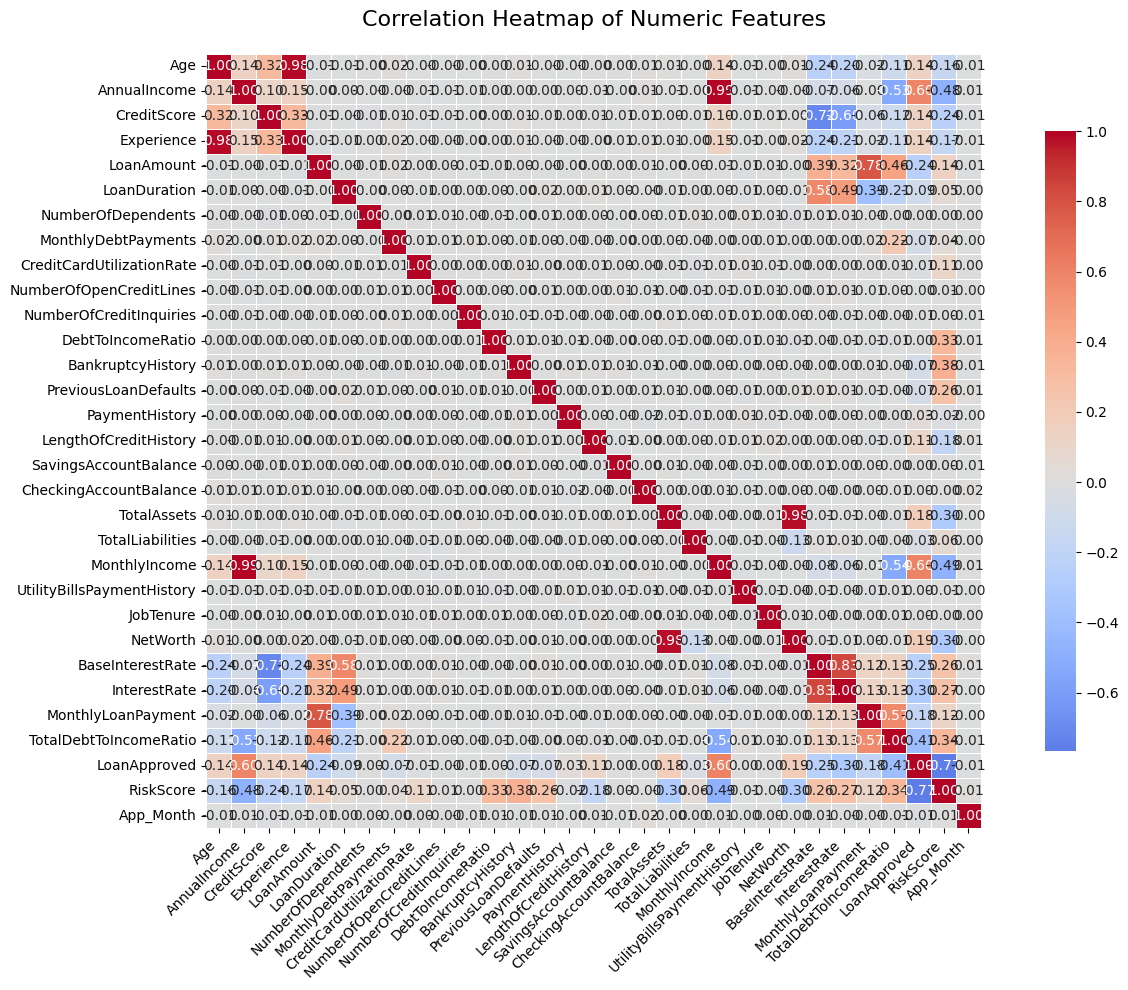

In [ ]:
# Select all numeric columns (including LoanApproved and RiskScore)
numeric_data = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,                
    fmt='.2f',                 
    cmap='coolwarm',           
    center=0,                  
    square=True,               
    linewidths=0.5,            
    cbar_kws={"shrink": .8}    
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

scaling 


In [635]:
df[['EmploymentStatus'
    ]].value_counts()
df[['ApplicationDate'
    ]].value_counts()

ApplicationDate
2018-01-01         1
2054-07-01         1
2054-07-08         1
2054-07-07         1
2054-07-06         1
                  ..
2036-04-02         1
2036-04-01         1
2036-03-31         1
2036-03-30         1
2072-10-03         1
Name: count, Length: 20000, dtype: int64

In [636]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])

df['App_Year'] = df['ApplicationDate'].dt.year
df['App_Month'] = df['ApplicationDate'].dt.month


In [637]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,App_Year,App_Month
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,2018,1
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,2018,1
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,2018,1
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,2018,1
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,2018,1


In [638]:
df.drop(columns=['ApplicationDate'], inplace=True)


In [639]:
df.drop(columns=['App_Year'], inplace=True)

In [640]:
df["App_Month"].value_counts()

App_Month
1     1705
3     1705
5     1705
7     1705
8     1705
10    1677
12    1674
4     1650
6     1650
9     1650
11    1620
2     1554
Name: count, dtype: int64

In [641]:
num_col = df.select_dtypes(include=["number"]).columns
cat_col = df.select_dtypes(include=["object", "bool"]).columns


In [642]:
num_col = num_col.drop(["LoanApproved" ,"RiskScore"])

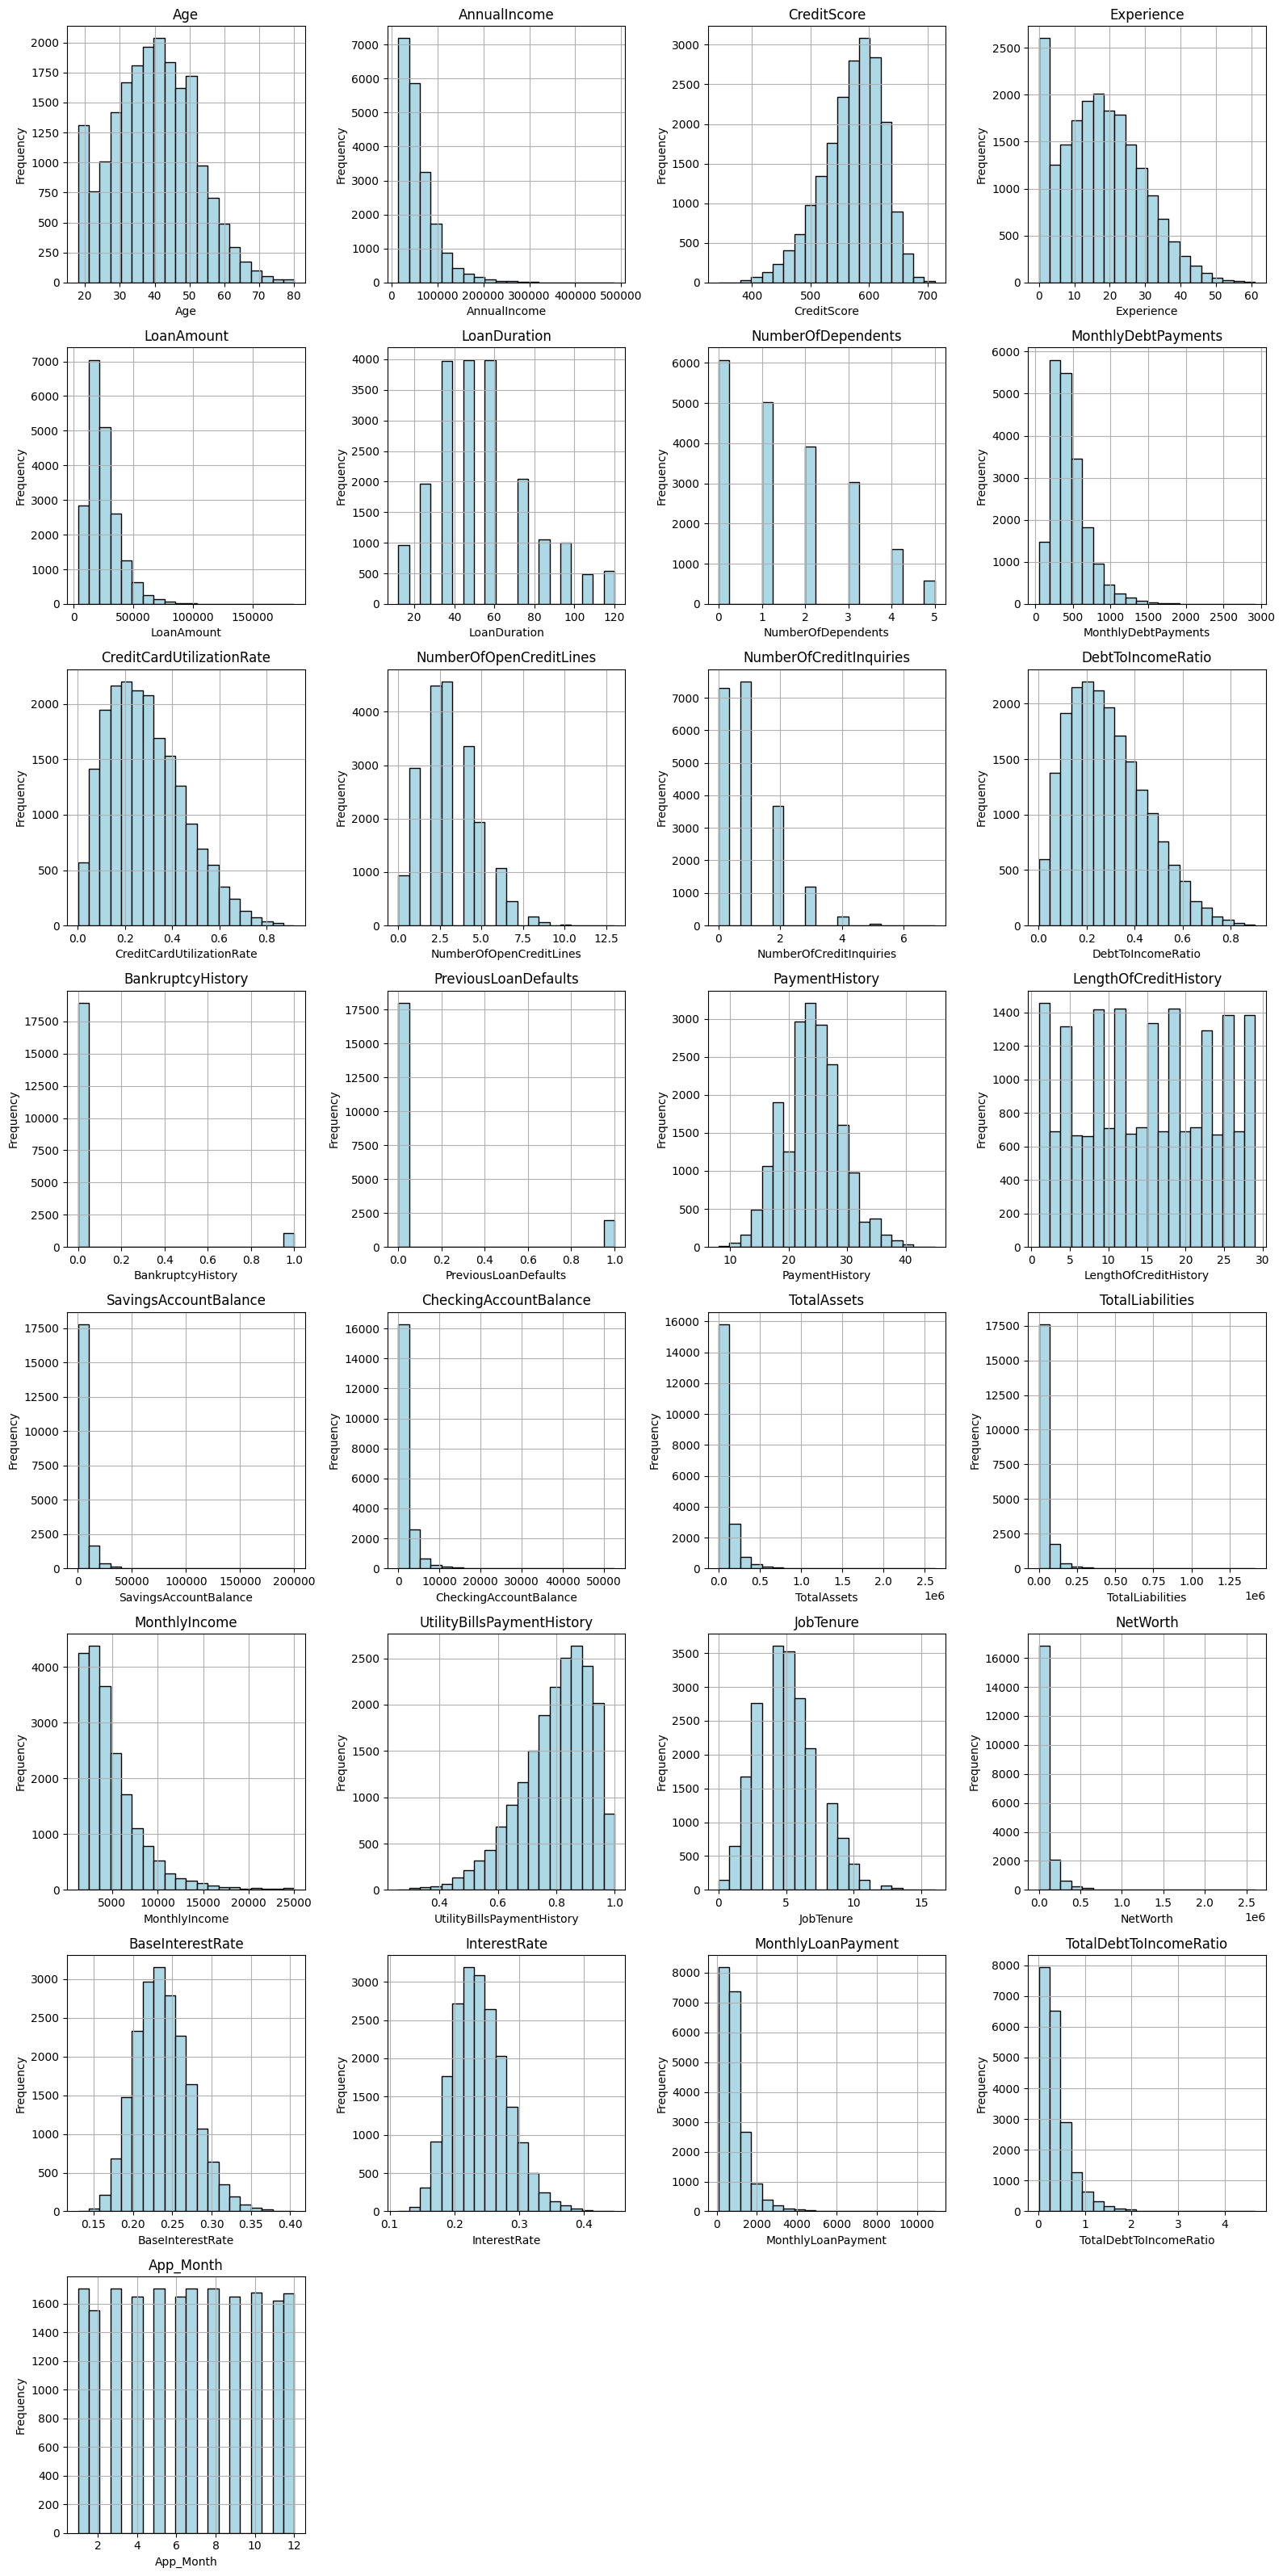

In [643]:
n_cols = 4
n_rows = (len(num_col) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(num_col):
    plt.subplot(n_rows, n_cols, i + 1)
    df[col].hist(bins=20, color='lightblue', edgecolor='black')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

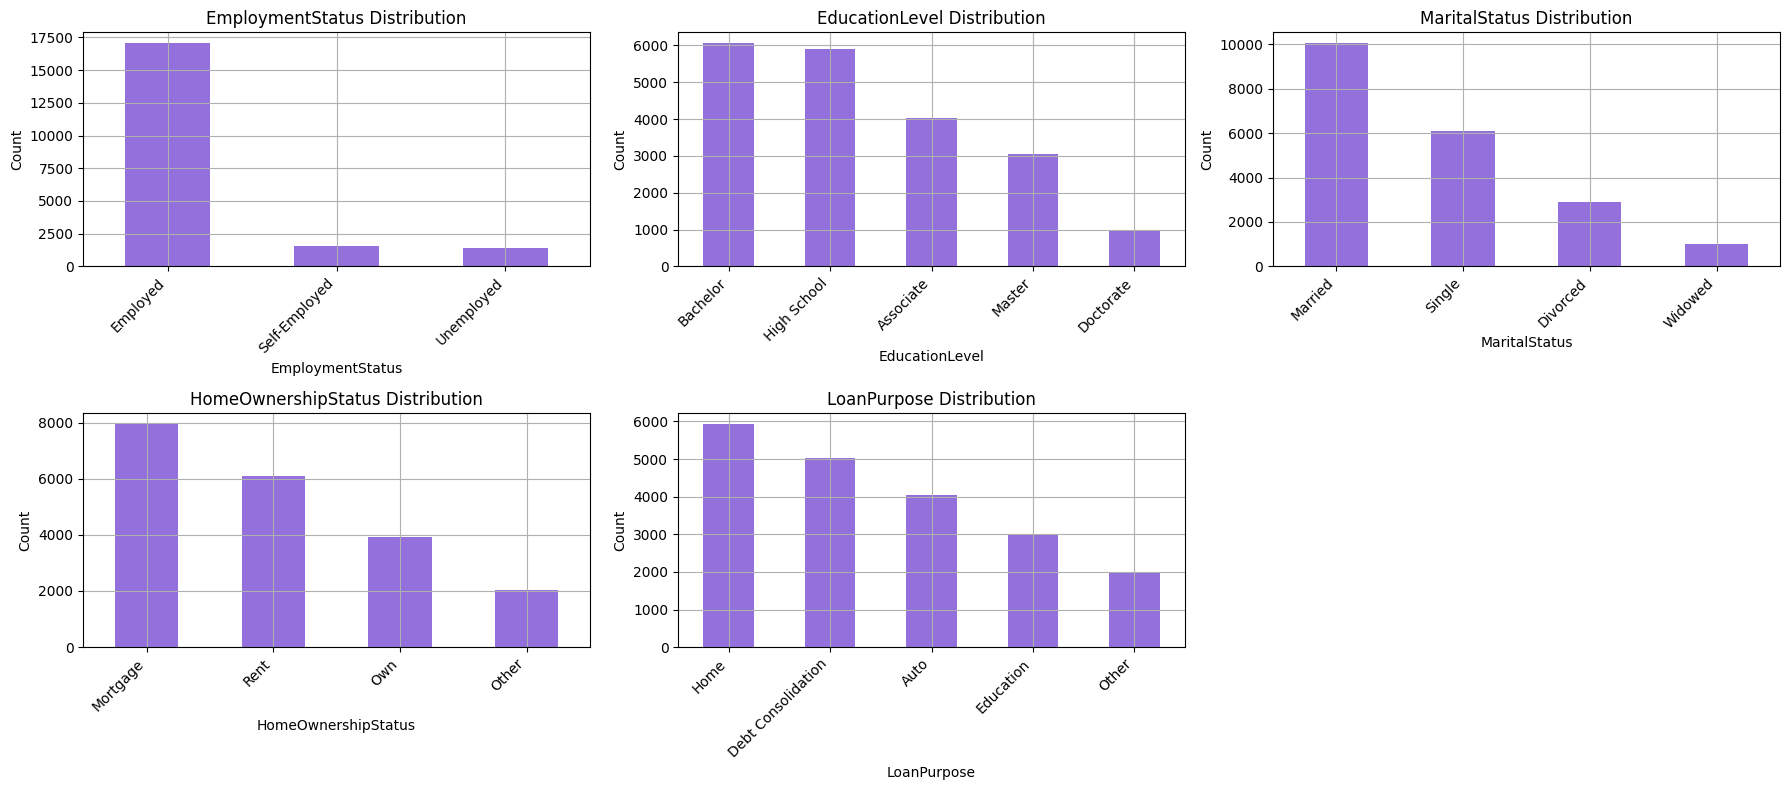

In [668]:
cat_col = [col for col in cat_col if col != 'ApplicationDate']

n_cols = 3
n_rows = (len(cat_col) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))
for i, col in enumerate(cat_col):
    plt.subplot(n_rows, n_cols, i + 1)
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar', color='mediumpurple')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True)
plt.tight_layout()
plt.show()

In [645]:
df[num_col].head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,App_Month
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,1
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,1
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,1
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,1
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1


In [646]:
df['LoanPurpose'].value_counts()

LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64

In [647]:
for c in cat_col:
    print(df[[c]].value_counts())

EmploymentStatus
Employed            17036
Self-Employed        1573
Unemployed           1391
Name: count, dtype: int64
EducationLevel
Bachelor          6054
High School       5908
Associate         4034
Master            3050
Doctorate          954
Name: count, dtype: int64
MaritalStatus
Married          10041
Single            6078
Divorced          2882
Widowed            999
Name: count, dtype: int64
HomeOwnershipStatus
Mortgage               7939
Rent                   6087
Own                    3938
Other                  2036
Name: count, dtype: int64
LoanPurpose       
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


In [648]:
employment_order = ['Unemployed', 'Self-Employed', 'Employed']
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']


In [649]:
ordinal_cols = ['EmploymentStatus', 'EducationLevel']
onehot_cols = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

In [650]:
num_transformer = Pipeline(steps=[
    ("impute ",SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler()),
])

In [651]:
num_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [652]:
ordinal_transformer = Pipeline(steps=[
    ("impute ",SimpleImputer(strategy="most_frequent")),
    ("encode",OrdinalEncoder(categories=[employment_order, education_order]))
])

In [653]:
OneHot_transformer = Pipeline(steps=[
    ("impute ",SimpleImputer(strategy="most_frequent")),
    ("encode",OneHotEncoder(handle_unknown="ignore")),
])

In [654]:
preprocess = ColumnTransformer(
    transformers=[
        ("num",num_transformer,num_col),
        ("ordinal",ordinal_transformer,ordinal_cols),
        ("onehot",OneHot_transformer,onehot_cols),
    ]
)

In [655]:
preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', num_tree, num_col),
        ('ordinal', ordinal_transformer, ordinal_cols),
        ('onehot', OneHot_transformer, onehot_cols)
    ]
)

In [656]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [657]:
X = df.drop(columns=['LoanApproved',"RiskScore"])
y = df['LoanApproved']

In [658]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [659]:
# clf_rf = Pipeline(steps=[
#     ('preprocess', preprocess_tree),
#     ('classifier', RandomForestClassifier(
#         class_weight='balanced',
#         n_estimators=300,
#         random_state=42
#     ))
# ])


In [660]:
# clf_rf.fit(X_train, y_train)

In [661]:
# y_pred =clf_rf.predict(X_test)

In [662]:
# print("Classification Report" ,classification_report(y_test,y_pred))

In [663]:
# import seaborn as sns

# # Confusion matrix
# conf_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

# plt.figure(figsize=(6,5))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()


In [664]:
clf_rf = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# B. Logistic Regression (Requires Scaled Data)
clf_log = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

clf_xgb = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight, # Helps with imbalance
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    "Random Forest": clf_rf,
    "Logistic Regression": clf_log,
    "XGBoost": clf_xgb
}

Training Random Forest....
Results for Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3044
           1       0.91      0.80      0.85       956

    accuracy                           0.93      4000
   macro avg       0.92      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000

The Accuracy is : 93.2%


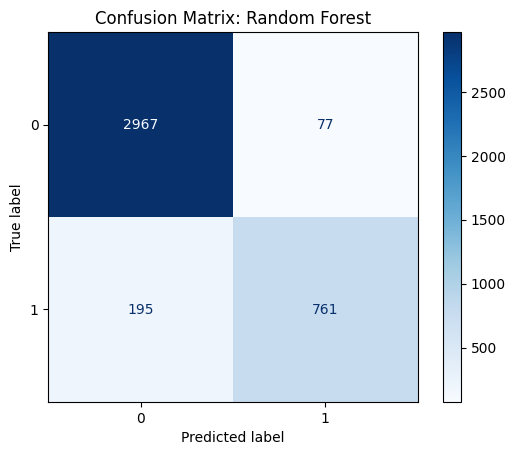

Training Logistic Regression....
Results for Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3044
           1       0.87      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000

The Accuracy is : 95.975%


c:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


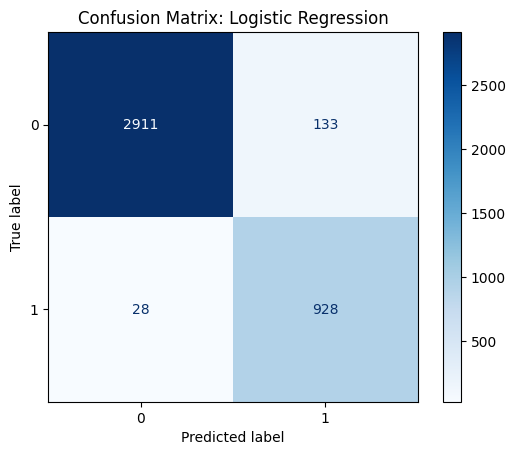

Training XGBoost....


c:\Users\pc\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:06:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Results for XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3044
           1       0.88      0.94      0.91       956

    accuracy                           0.96      4000
   macro avg       0.93      0.95      0.94      4000
weighted avg       0.96      0.96      0.96      4000

The Accuracy is : 95.55%


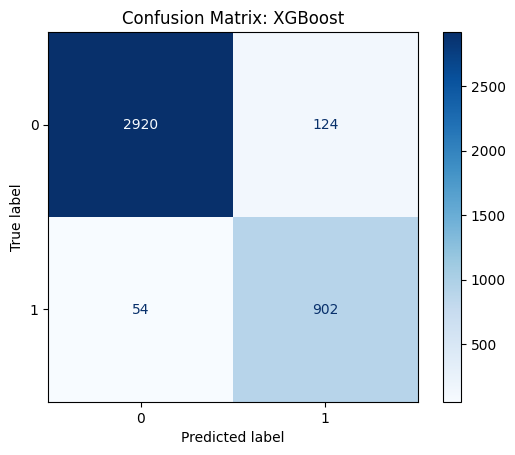

In [665]:
import time
for name,  model in models.items():
    print(f"Training {name}....")
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"Results for {name}:")
    print(classification_report(y_test,y_pred))
    print(f"The Accuracy is : {accuracy_score(y_test,y_pred)*100}%")
    # plot_confusion(y_test, y_pred, title=f'Confusion Matrix: {name}')
    disp = ConfusionMatrixDisplay.from_estimator(
        model, 
        X_test, 
        y_test,
        cmap=plt.cm.Blues,
        values_format='d'
    )
    disp.ax_.set_title(f'Confusion Matrix: {name}')
    plt.show()
    time.sleep(3)
    


Generating Evaluation Charts...


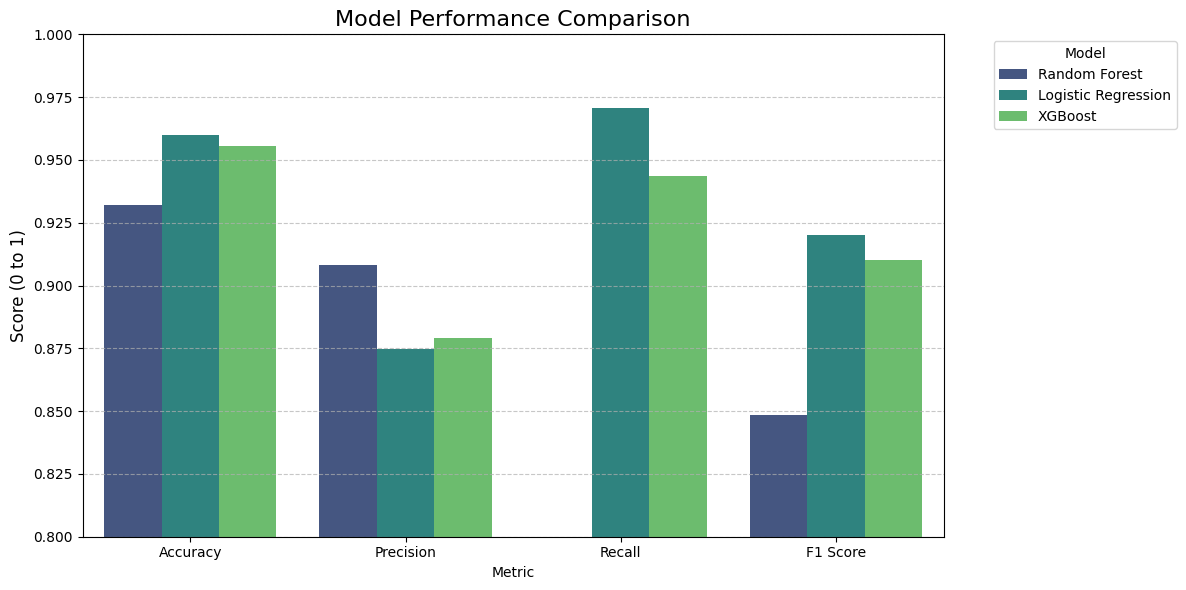

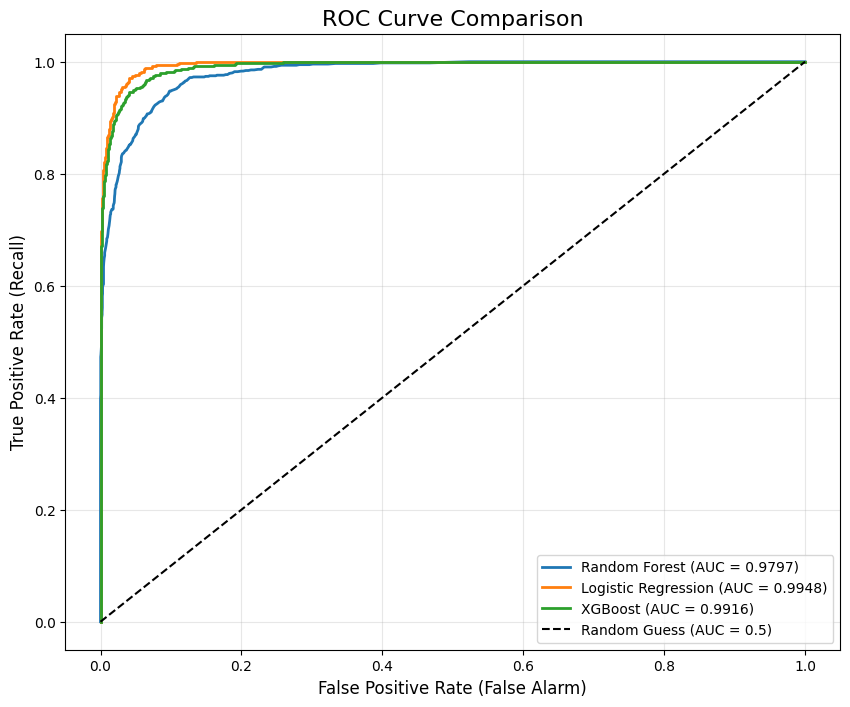

C:\Users\pc\AppData\Local\Temp\ipykernel_22048\2551808960.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='rocket')


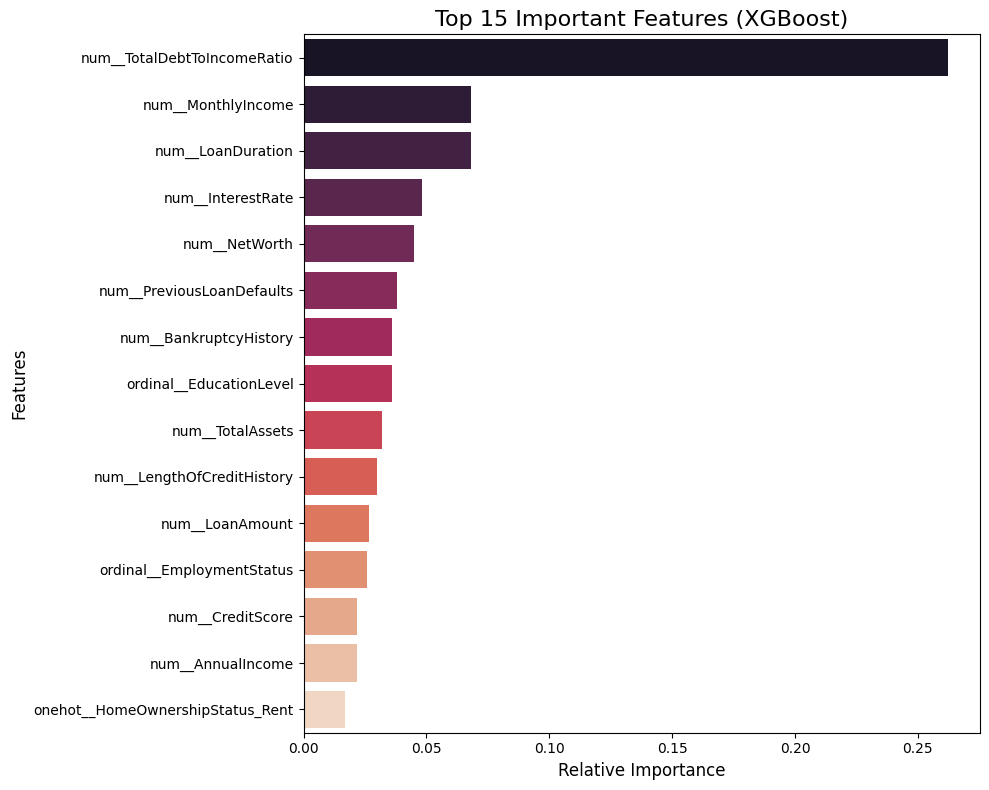

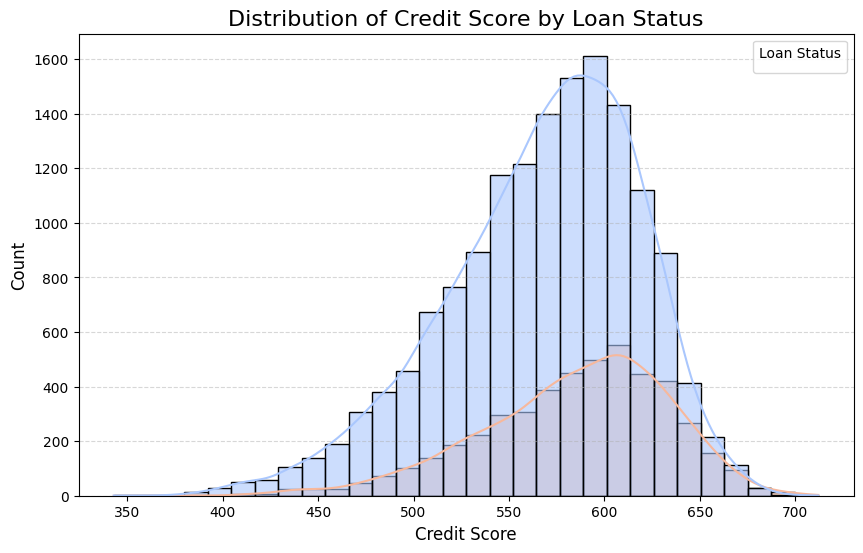

In [666]:
# ==========================================
# 1. COLLECT METRICS FOR COMPARISON
# ==========================================

# Initialize a list to store results
evaluation_results = []

# Dictionary to store ROC curve data
roc_data = {}

print("\nGenerating Evaluation Charts...")

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probabilities (needed for ROC AUC and plotting)
    # Some models might not have predict_proba, but yours do
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store metrics
    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    # Store ROC data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, y_proba))

# Create a DataFrame for easier plotting
results_df = pd.DataFrame(evaluation_results)

# Melt the DataFrame for seaborn barplot
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# ==========================================
# 2. CHART 1: MODEL COMPARISON (The "Model Chart")
# ==========================================
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x="Metric", y="Score", hue="Model", data=results_melted, palette="viridis")
plt.title("Model Performance Comparison", fontsize=16)
plt.ylabel("Score (0 to 1)", fontsize=12)
plt.ylim(0.8, 1.0) # Zoom in a bit since all scores are high
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# 3. CHART 2: ROC CURVE (Trade-off Analysis)
# ==========================================
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

# Plot the diagonal line (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.title('ROC Curve Comparison', fontsize=16)
plt.xlabel('False Positive Rate (False Alarm)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# 4. CHART 3: FEATURE IMPORTANCE (Why did the model decide?)
# ==========================================
# Let's use XGBoost for this as it's usually the most robust model

# Extract the trained XGBoost model from the pipeline
xgb_model = clf_xgb.named_steps['classifier']
preprocessor = clf_xgb.named_steps['preprocess']

# Get feature names after transformation (OneHotEncoding creates new columns)
try:
    # For newer sklearn versions
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback for older versions (Manual construction)
    num_features = list(num_col)
    ord_features = list(ordinal_cols)
    # Get OHE feature names
    ohe = preprocessor.named_transformers_['onehot'].named_steps['encode']
    ohe_features = ohe.get_feature_names_out(onehot_cols)
    feature_names = num_features + ord_features + list(ohe_features)

# Get importances
importances = xgb_model.feature_importances_

# Create a DataFrame for plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15) # Top 15 features

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='rocket')
plt.title('Top 15 Important Features (XGBoost)', fontsize=16)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 5. CHART 4: DISTRIBUTION OF CREDIT SCORE
# (High-value business chart)
# ==========================================

plt.figure(figsize=(10, 6))
# We use the original df for this, but let's just plot the distribution
sns.histplot(data=df, x='CreditScore', hue='LoanApproved', kde=True, bins=30, palette='coolwarm', alpha=0.6)
plt.title('Distribution of Credit Score by Loan Status', fontsize=16)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
# Add a legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Rejected (0)', 'Approved (1)'], title='Loan Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()